#### This file finds the scattering parameter and adds it to the data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#### Import Data

In [3]:
experimental_path = "Spectral_library_experimental_scattering.xlsx"
df_experimental = pd.read_excel(experimental_path)

clean_path = "Spectral_library_clean.xlsx"
df_clean = pd.read_excel(clean_path)

#### Compare Experimental Scattering Data with Unscattered Data

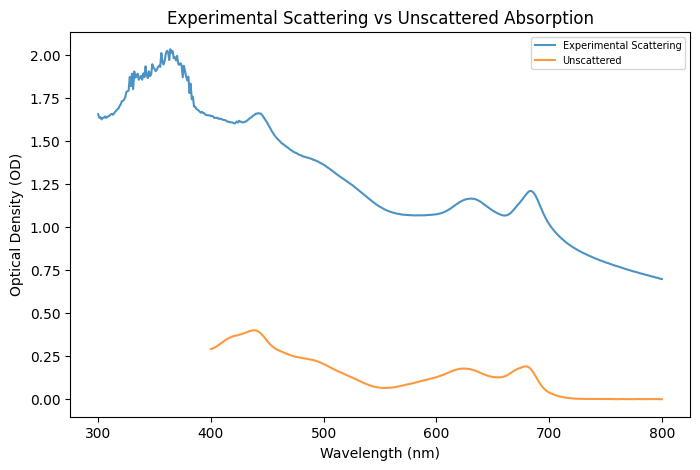

In [5]:
wavelength_col = "Wavelength"
cyano_col = "Cyanobacteria_Synechosystis"

experimental_wavelengths = df_experimental[wavelength_col].values
experimental_spectrum = df_experimental[cyano_col].values
unscattered_wavelengths = df_clean[wavelength_col].values
unscattered_spectrum = df_clean[cyano_col].values


plt.figure(figsize=(8, 5))
plt.plot(experimental_wavelengths, experimental_spectrum, label="Experimental Scattering", alpha=0.8)
plt.plot(unscattered_wavelengths, unscattered_spectrum, label="Unscattered", alpha=0.8)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Optical Density (OD)")
plt.title("Experimental Scattering vs Unscattered Absorption")
plt.legend(fontsize=7)
plt.show()

#### Fit scattering

In [30]:
def fitting_function(wavelengths_nm, a, n, c):
    lam = wavelengths_nm.astype(float)
    lambda_ref = 550
    return a * (lam / lambda_ref) ** (-n) + c

mask = (experimental_wavelengths >= 770) & (experimental_wavelengths <= 800)
wl_fit = experimental_wavelengths[mask]
A_fit  = experimental_spectrum[mask]

p0 = (0.1, 1.0, 0.0)
popt, pcov = curve_fit(fitting_function, wl_fit, A_fit, p0=p0)
a_hat, n_hat, c_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  n={n_hat:.4f},  c={c_hat:.6f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δn={perr[1]:.4f},  Δc={perr[2]:.6f}")

Fitted parameters:  a=1.5459,  n=1.6393,  c=-0.138705
Parameter uncertainties:  Δa=0.2580,  Δn=0.6556,  Δc=0.345157


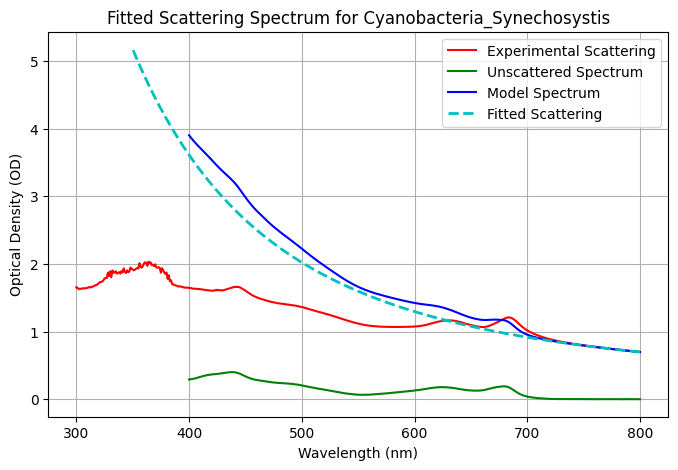

In [64]:
wl_full = unscattered_wavelengths
A_full = unscattered_spectrum
fitted_scattering = fitting_function(wl_full, a=a_hat, n=n_hat, c=c_hat)

model_spectrum = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(experimental_wavelengths, experimental_spectrum, 'r', label='Experimental Scattering', markersize=4)
plt.plot(unscattered_wavelengths, unscattered_spectrum, 'g', label='Unscattered Spectrum')
plt.plot(wl_full, model_spectrum, 'b', label='Model Spectrum')
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Fitted Scattering Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()


#### Fit on scattering only

Fitted parameters:  a=1.3712,  n=2.8409,  c=0.2250
Parameter uncertainties:  Δa=0.0078,  Δn=0.9393,  Δc=0.1651


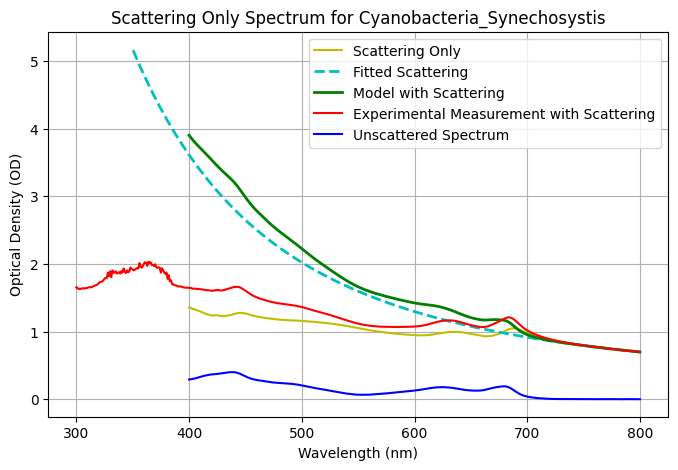

In [81]:
scattering_only = pd.DataFrame(columns=["Wavelength", "Optical Density"])
mask = (experimental_wavelengths >= 350) & (experimental_wavelengths <= 800)
scattering_only["Wavelength"] = experimental_wavelengths[mask]
scattering_only["Optical Density"] = experimental_spectrum[mask] - unscattered_spectrum

scattering_only_wavelengths = scattering_only["Wavelength"]
scattering_only_optical_density = scattering_only["Optical Density"]

scattering_only["Optical Density"] = scattering_only["Optical Density"].replace(np.nan, 0)
mask = (scattering_only_wavelengths >= 770) & (scattering_only_wavelengths <= 800)
wl_fit = scattering_only_wavelengths[mask]
A_fit  = scattering_only_optical_density[mask]

p0 = (0.1, 0, 0.0)
popt, pcov = curve_fit(fitting_function, wl_fit, A_fit, p0=p0)
a_hat, n_hat, c_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  n={n_hat:.4f},  c={c_hat:.4f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δn={perr[1]:.4f},  Δc={perr[2]:.4f}")

wl_full = unscattered_wavelengths
A_full = unscattered_spectrum
fitted_scattering = fitting_function(wl_full, a=a_hat, n=n_hat, c=c_hat)
model_scattering_only = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(scattering_only_wavelengths, scattering_only_optical_density, 'y', label='Scattering Only', markersize=4)
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.plot(wl_full, model_scattering_only, 'g', label='Model with Scattering', linewidth=2)
plt.plot(experimental_wavelengths, experimental_spectrum, 'r', label='Experimental Measurement with Scattering', markersize=4)
plt.plot(unscattered_wavelengths, unscattered_spectrum, 'b', label='Unscattered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Scattering Only Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()

Fitted parameters:  a=-0.0014,  b=1.8307
Parameter uncertainties:  Δa=0.0000,  Δb=0.0124


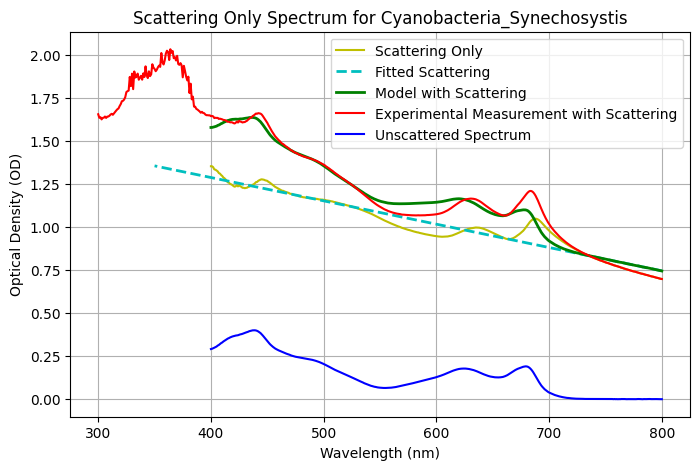

In [ ]:
def linear_fitting_function(wavelengths_nm, a, b):
        return a * wavelengths_nm + b

scattering_only = pd.DataFrame(columns=["Wavelength", "Optical Density"])
mask = (experimental_wavelengths >= 350) & (experimental_wavelengths <= 800)
scattering_only["Wavelength"] = experimental_wavelengths[mask]
scattering_only["Optical Density"] = experimental_spectrum[mask] - unscattered_spectrum

scattering_only_wavelengths = scattering_only["Wavelength"]
scattering_only_optical_density = scattering_only["Optical Density"]

scattering_only["Optical Density"] = scattering_only["Optical Density"].replace(np.nan, 0)
mask = (scattering_only_wavelengths >= 400) & (scattering_only_wavelengths <= 800)
wl_fit = scattering_only_wavelengths[mask]
A_fit  = scattering_only_optical_density[mask]

p0 = (0.1, 1.0)
popt, pcov = curve_fit(linear_fitting_function, wl_fit, A_fit, p0=p0)
a_hat, b_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  b={b_hat:.4f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δb={perr[1]:.4f}")

wl_full = unscattered_wavelengths
A_full = unscattered_spectrum
fitted_scattering = linear_fitting_function(wl_full, a=a_hat, b=b_hat)
model_scattering_only = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(scattering_only_wavelengths, scattering_only_optical_density, 'y', label='Scattering Only', markersize=4)
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.plot(wl_full, model_scattering_only, 'g', label='Model with Scattering', linewidth=2)
plt.plot(experimental_wavelengths, experimental_spectrum, 'r', label='Experimental Measurement with Scattering', markersize=4)
plt.plot(unscattered_wavelengths, unscattered_spectrum, 'b', label='Unscattered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Scattering Only Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()